In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("data/framingham.csv")

In [ ]:
# EDA

In [4]:
df.shape

(4240, 16)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 530.1 KB


In [3]:
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [6]:
df.isna().sum() #there is missing values
# glucose ,totChol , BMI, heartRate = (Median)
# cigsPerDay = (Median or who is not smoking fill with 0 )
# BPMeds = (mod)
# Education = (mod)

male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

In [76]:
df.duplicated().sum() # there is no duplicated

np.int64(0)

In [7]:
df.describe()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4240.000000,4240.000000,4135.000000,4240.000000,4211.000000,4187.000000,4240.000000,4240.000000,4240.000000,4190.000000,4240.000000,4240.000000,4221.000000,4239.000000,3852.000000,4240.000000
mean,0.429245,49.580189,1.979444,0.494104,9.005937,0.029615,0.005896,0.310613,0.025708,236.699523,132.354599,82.897759,25.800801,75.878981,81.963655,0.151887
std,0.495027,8.572942,1.019791,0.500024,11.922462,0.169544,0.076569,0.462799,0.158280,44.591284,22.033300,11.910394,4.079840,12.025348,23.954335,0.358953
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,90.000000,28.040000,83.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


In [ ]:
#The highest values sysBP = 296 and totChol = 696 look very high, but they are still possible in real patients with severe conditions. There are no impossible values like a blood pressure of 0. So I think these are real high-risk patients, not errors, and I keep them instead of deleting them.

In [17]:
df["TenYearCHD"].value_counts(normalize=True)* 100# Target is TenYearCHD but there is imbalanced data , approxi

TenYearCHD
0    84.811321
1    15.188679
Name: proportion, dtype: float64

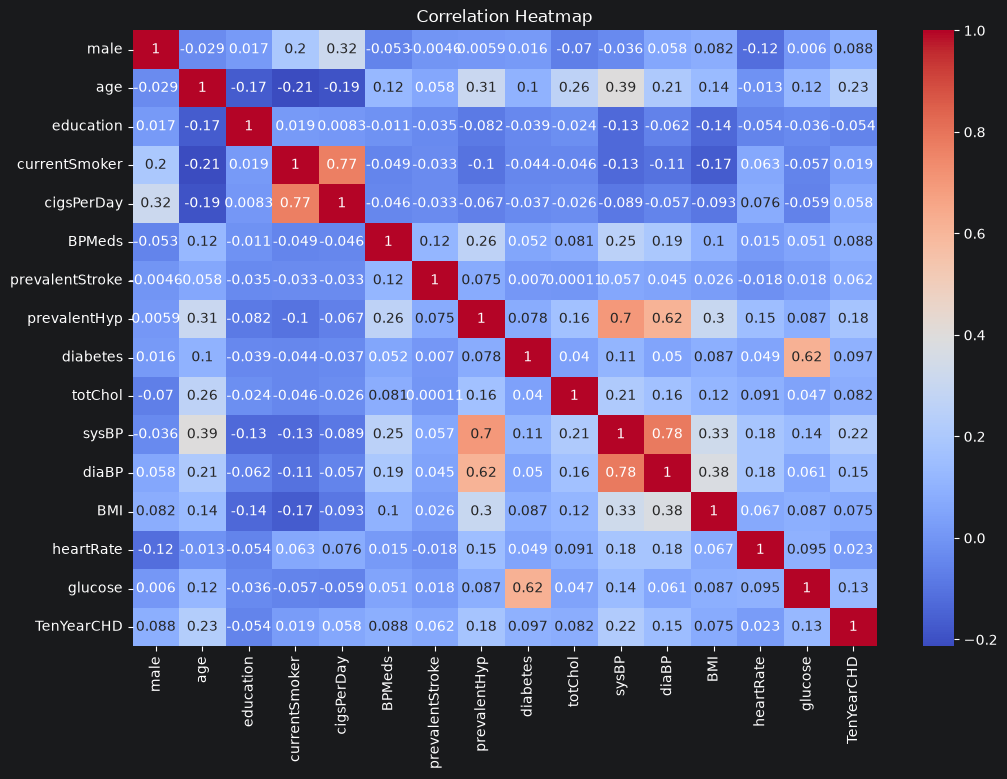

In [60]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
# No single feature determines the disease on its own; the risk comes from a combination of many factors. That's why I am going to use an ML model that evaluates all features together.

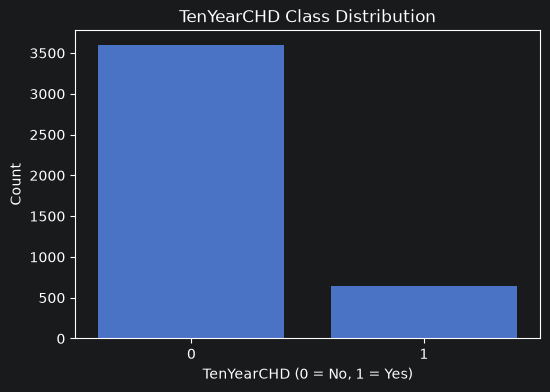

In [61]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="TenYearCHD")
plt.title("TenYearCHD Class Distribution")
plt.xlabel("TenYearCHD (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

In [ ]:
#The dataset is imbalanced: about 85% of patients are in class 0 (no CHD) and only ~15% in class 1 (CHD). Because of this, accuracy would be misleading. That's why I will use recall and ROC-AUC as the main metrics and try balancing techniques such as class_weight or SMOTE.

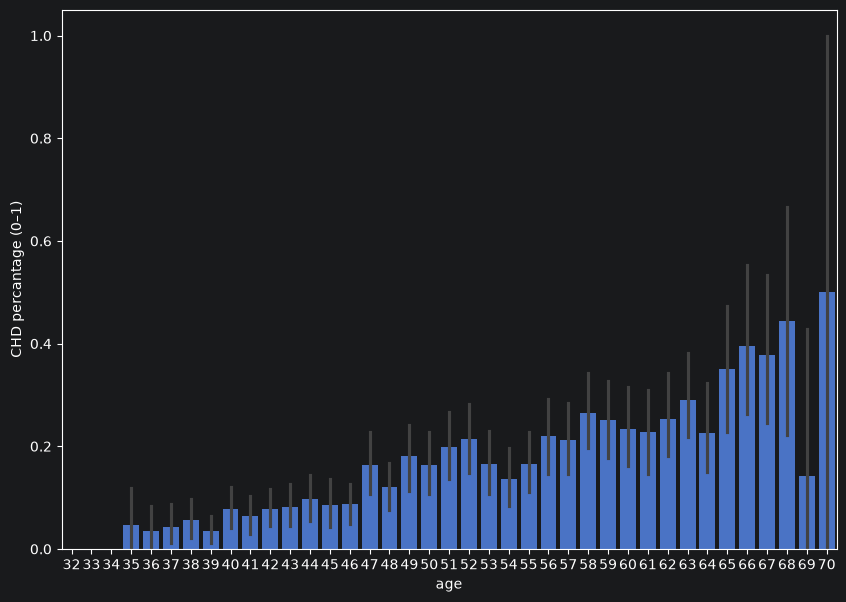

In [42]:
plt.figure(figsize=(10,7))
sns.barplot(data=df, x="age", y="TenYearCHD")
plt.ylabel("CHD percantage (0–1)")
plt.show()

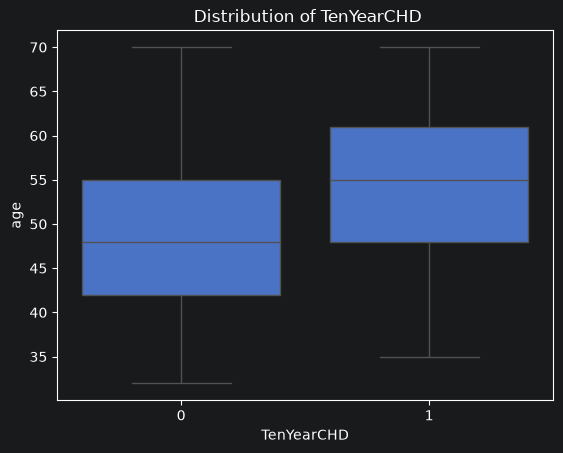

In [44]:
sns.boxplot(data=df, x="TenYearCHD", y="age")
plt.title("Distribution of TenYearCHD")
plt.show()
plt.show()

In [ ]:
# Barplot and boxplot , shows high correlletion between CHD and age . When age increases CHD percantage also increasing .The CHD positive group (TenYearCHD = 1) has a higher median age (~55) than the CHD-negative group (~47), indicating that age is an important risk factor.

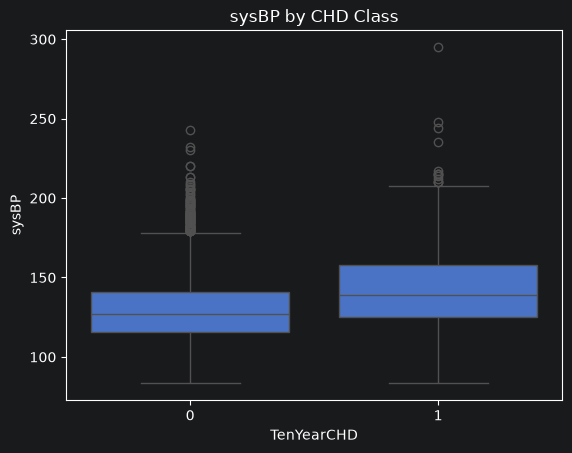

In [74]:
sns.boxplot(data=df, x="TenYearCHD", y="sysBP")
plt.title("sysBP by CHD Class")
plt.show()

In [ ]:
# People who got heart disease (class 1) have higher blood pressure than those who didn't (class 0). We can see the box for class 1 is higher. This matches the correlation we saw earlier, so blood pressure looks like an important risk factor. There are also some very high values (outliers), but these are probably real patients with high blood pressure, not mistakes.